In [ ]:
from pathlib import Path
import sys

from srcs.simulation.data import PARAM_COLS, open_pool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

In [16]:
DATA_PATH = '../data/'
pool = open_pool(DATA_PATH, stage=1, split="test")
df_ic = pd.DataFrame(pool.params, columns=list(PARAM_COLS))
df_ic

,theta10,theta20,omega10,omega20,m1,m2,l,g
0,-1.258446,-0.485770,-2.830082,-2.254300,1.0,1.0,1.0,0.0
1,1.072064,0.924818,0.692311,-0.697935,1.0,1.0,1.0,0.0


In [17]:
n, nt = pool.n_traj, pool.n_t
df = pd.DataFrame({
  "traj": np.repeat(np.arange(n), nt),
  "t": np.tile(pool.t, n),
  "sin_theta1": pool.sin_theta1.ravel(),
  "cos_theta1": pool.cos_theta1.ravel(),
  "sin_theta2": pool.sin_theta2.ravel(),
  "cos_theta2": pool.cos_theta2.ravel(),
  "omega1": pool.omega1.ravel(),
  "omega2": pool.omega2.ravel(),
  "energy": pool.energy.ravel(),
})
# glue ICs onto every time row
df = df.join(df_ic, on="traj")
df

,traj,t,sin_theta1,cos_theta1,sin_theta2,cos_theta2,omega1,omega2,energy,theta10,theta20,omega10,omega20,m1,m2,l,g
0,0,0.000000,-0.951614,0.307296,-0.466890,0.884316,-2.830082,-2.254300,15.118563,-1.258446,-0.485770,-2.830082,-2.254300,1.0,1.0,1.0,0.0
1,0,0.004167,-0.955158,0.296096,-0.475245,0.879853,-2.808846,-2.292638,15.118563,-1.258446,-0.485770,-2.830082,-2.254300,1.0,1.0,1.0,0.0
2,0,0.008333,-0.958546,0.284939,-0.483698,0.875235,-2.787441,-2.330766,15.118563,-1.258446,-0.485770,-2.830082,-2.254300,1.0,1.0,1.0,0.0
3,0,0.012500,-0.961778,0.273831,-0.492244,0.870457,-2.765863,-2.368682,15.118563,-1.258446,-0.485770,-2.830082,-2.254300,1.0,1.0,1.0,0.0
4,0,0.016667,-0.964858,0.262773,-0.500879,0.865517,-2.744106,-2.406388,15.118563,-1.258446,-0.485770,-2.830082,-2.254300,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,1,9.983333,0.498943,0.866635,0.833162,-0.553030,0.461154,-0.226251,0.244891,1.072064,0.924818,0.692311,-0.697935,1.0,1.0,1.0,0.0
4798,1,9.987500,0.500607,0.865675,0.833684,-0.552242,0.461234,-0.227131,0.244891,1.072064,0.924818,0.692311,-0.697935,1.0,1.0,1.0,0.0
4799,1,9.991667,0.502270,0.864711,0.834207,-0.551452,0.461316,-0.228011,0.244891,1.072064,0.924818,0.692311,-0.697935,1.0,1.0,1.0,0.0
4800,1,9.995833,0.503931,0.863744,0.834731,-0.550657,0.461399,-0.228892,0.244891,1.072064,0.924818,0.692311,-0.697935,1.0,1.0,1.0,0.0


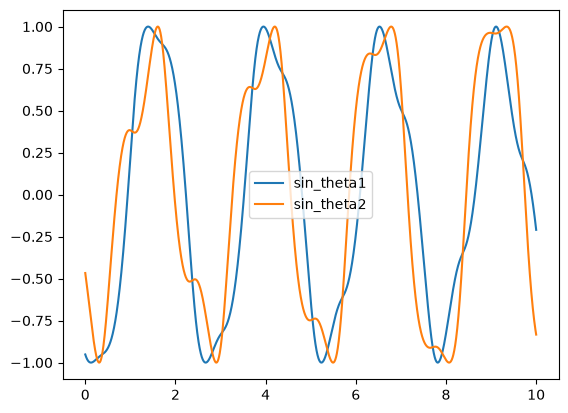

In [18]:
m = df.traj == 0
plt.plot(df.t[m], df.sin_theta1[m],label="sin_theta1")
plt.plot(df.t[m], df.sin_theta2[m],label="sin_theta2")
plt.legend()
plt.show()


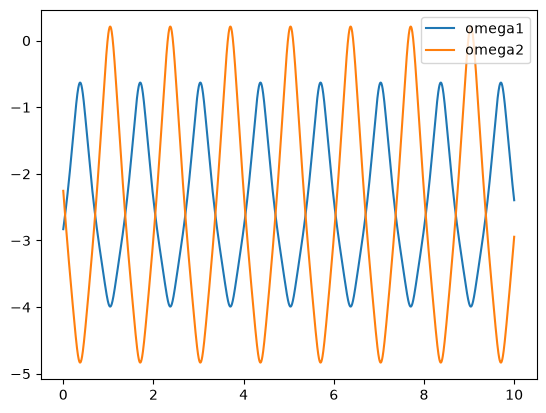

In [19]:
m = df.traj == 0
plt.plot(df.t[m], df.omega1[m],label="omega1")
plt.plot(df.t[m], df.omega2[m],label="omega2")
plt.legend()
plt.show()